In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scipy.interpolate as interp
from scipy.ndimage import gaussian_filter1d

import IIF_analysis as IIF

datadir = '/Users/idse/data_tmp/signaldecoding/'

# which signals and genes are in the data depends on the experiment and should be defined for each dataset
signal_names = ['pSMAD1','ncYAP','BCat','LEF1','ncSMAD23','cytopERK','cytopAKT'] #'ncSMAD2'
signal_names_simplified = ['SMAD1','YAP','BCat','LEF1','SMAD23','ERK','AKT'] # 'SMAD2',

gene_names = ['ISL1','GATA3','HAND1','CDX2','TFAP2C','SOX17_1','PRDM1','SNAI1','MIXL1','TBXT','EOMES','TBX6','OCT4','NANOG','SOX2','OTX2']
gene_names_simplified = ['ISL1','GATA3','HAND1','CDX2','TFAP2C','SOX17','PRDM1','SNAI1','MIXL1','TBXT','EOMES','TBX6','OCT4','NANOG','SOX2','OTX2']

feature_names = ['nucArea', 'nucVolume','nucMajorAxis', 'nucMinorAxis', 'nucCircularity', 'CircleEdgeDist']

# plotting parameters
fs = 14
lw = 2
plt.rcParams['figure.figsize'] = [4, 4]
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['lines.linewidth'] = lw
plt.rcParams['axes.linewidth'] = lw

# from Seth's script 
thresholds = {'ISL1': 350, 'TFAP2C': 522, 'SOX17': 254, 'NANOG': 920, 'TBX6': 508, 'TBXT': 240, 'SOX2': 742}

In [58]:
def rename_pred_cols(df, suffix):
    df = df.copy()
    df.columns = [col.replace('_pred', f'_{suffix}') if col.endswith('_pred') else col for col in df.columns]
    return df

B50_pred = pd.read_csv(datadir + 'ExpX7_predictions_from_B50_model.csv')
B50_pred.loc[B50_pred['Train or Test']==0, 'Train or Test']=2 # 0 and 2 both represent testing data
B50_pred.rename(columns={'Train or Test': 'test'}, inplace=True)
B50_pred['test'] = B50_pred['test']==2

joint_pred = pd.read_csv(datadir + 'ExpX7_predictions_from_joint_model.csv')
joint_pred.rename(columns={'Train or Test': 'test'}, inplace=True)
joint_pred['test'] = joint_pred['test']==2

# restrict both predictions to truli test data for joint model to make fair comparison
B50_pred = B50_pred[joint_pred['test']==True].drop(columns=['test'])
joint_pred = joint_pred[joint_pred['test']==True].drop(columns=['test'])

# rename columns before merging
B50_pred = rename_pred_cols(B50_pred, 'B50pred')
joint_pred = rename_pred_cols(joint_pred, 'jointpred')

pred_comb = pd.concat([B50_pred, joint_pred[[c for c in joint_pred.columns if 'pred' in c]]], axis=1)
pred_comb.columns

conditions = list(np.unique(pred_comb['Condition']))

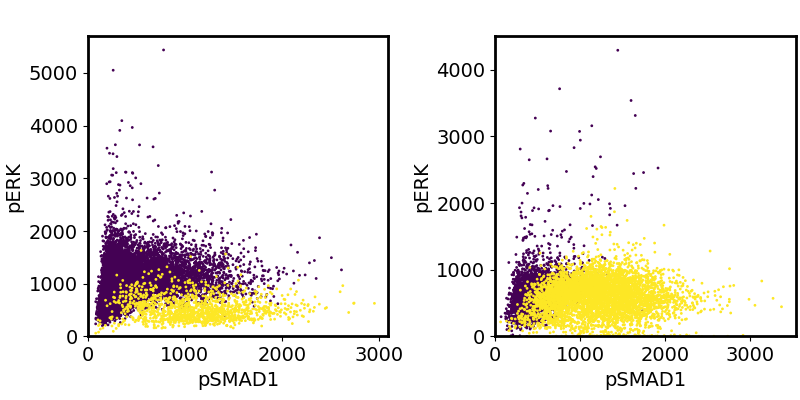

In [59]:
def subscatter(ax, xchan, ychan, cchan, condition, discretize=True):
    
    condidx = pred_comb['Condition']==condition
    
    x = pred_comb.loc[condidx, xchan]
    y = pred_comb.loc[condidx, ychan]
    col = pred_comb.loc[condidx, cchan]
    
    if discretize:
        col = col > thresholds[cchan.split('_')[0]]
    i = col.sort_values().index
    
    ax.scatter(x[i], y[i], s=1, c=col[i])
    ax.set_xlabel(xchan)
    ax.set_ylabel(ychan)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_box_aspect(1)

nrows=1; ncols=2
fig, ax = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)

xchan = 'pSMAD1'
ychan = 'pERK'
cchan = 'ISL1_B50pred'

subscatter(ax[0], xchan, ychan, cchan, condition='B50')
subscatter(ax[1], xchan, ychan, cchan, condition='B50T30')

In [60]:
def subscatter_truefalse(ax, xchan, ychan, cchan, condition, model):
    
    condidx = pred_comb['Condition']==condition
    notcondidx = pred_comb['Condition']!=condition

    x = pred_comb.loc[notcondidx, xchan]
    y = pred_comb.loc[notcondidx, ychan]

    ax.scatter(x[notcondidx], y[notcondidx], s=1, label='other cond', color='lightgray')
    
    x = pred_comb.loc[condidx, xchan]
    y = pred_comb.loc[condidx, ychan]
    
    pred = pred_comb.loc[condidx, cchan + '_' + model + 'pred'] > thresholds[cchan]
    exp =  pred_comb.loc[condidx, cchan] > thresholds[cchan]

    truepos = pred & exp
    falsepos = pred & ~exp
    negative = ~truepos & ~falsepos

    #print('#true pos: ' + str(np.sum(truepos)))

    ax.scatter(x[negative],    y[negative],    s=1, label='N: '+ str(np.sum(negative)))
    ax.scatter(x[falsepos], y[falsepos], s=1, label='FP: ' + str(np.sum(falsepos)))
    ax.scatter(x[truepos],  y[truepos],  s=1, label='TP: '+ str(np.sum(truepos)))
    
    ax.set_xlabel(xchan)
    ax.set_ylabel(ychan)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_box_aspect(1)
    
    ax.legend(markerscale=5, fontsize=9, loc='best')
    ax.set_title(cchan + ': ' + model + '->' + condition)

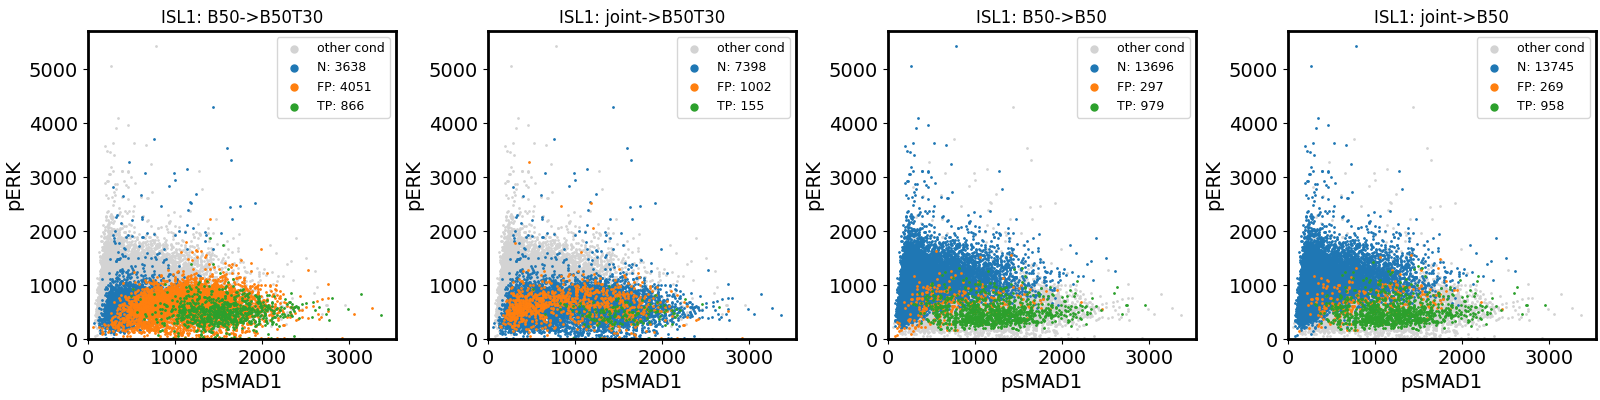

In [61]:
nrows=1; ncols=4
fig, ax = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)

xchan = 'pSMAD1'
ychan = 'pERK'
cchan = 'ISL1'

subscatter_truefalse(ax[0], xchan, ychan, cchan, model='B50', condition='B50T30')
subscatter_truefalse(ax[1], xchan, ychan, cchan, model='joint', condition='B50T30')
subscatter_truefalse(ax[2], xchan, ychan, cchan, model='B50', condition='B50')
subscatter_truefalse(ax[3], xchan, ychan, cchan, model='joint', condition='B50')

from matplotlib.widgets import RectangleSelector
# --- RectangleSelector part ---
selected_rect = None  # We'll use this variable to keep reference to the rectangle artist for visualization

def onselect(eclick, erelease):
    global selected_rect, selected_indices
    ax_sel = ax[0]  # <<< Select the axis you want to interact with!
    
    # Remove the old rectangle if present
    if selected_rect is not None:
        selected_rect.remove()
        fig.canvas.draw_idle()
    
    # Rectangle bounds
    x0, x1 = sorted([eclick.xdata, erelease.xdata])
    y0, y1 = sorted([eclick.ydata, erelease.ydata])
    
    # Which points were plotted on this axis?
    # Find the data used for this axis:
    xdata = pred_comb.loc[:, xchan]
    ydata = pred_comb.loc[:, ychan]

    # Select points inside the rectangle
    inside = (xdata >= x0) & (xdata <= x1) & (ydata >= y0) & (ydata <= y1)
    selected_indices = xdata.index[inside]
#    print("Indices of selected points:", list(selected_indices))

    # Visual feedback: draw the rectangle
    from matplotlib.patches import Rectangle
    selected_rect = Rectangle(
        (x0, y0), x1-x0, y1-y0, linewidth=1, fill=False, edgecolor='red'
    )
    ax_sel.add_patch(selected_rect)
    fig.canvas.draw_idle()
    
    fig.savefig(datadir + 'selection.png', dpi=300, bbox_inches='tight')

toggle_selector = RectangleSelector(
    ax[0], onselect, useblit=True, button=[1],
    minspanx=5, minspany=5, spancoords='data', interactive=True)

plt.show()

12258       B50
12274       B50
12286       B50
12312       B50
12358       B50
          ...  
44158    B50T30
44161    B50T30
44175    B50T30
44187    B50T30
44210    B50T30
Name: Condition, Length: 1440, dtype: object